In [1]:
import os 
# Get the current working directory
current_dir = os.getcwd()
print("Current working directory:", current_dir)

import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt # import matplotlib to visualize our qc metrics

# magic incantation to help matplotlib work with our jupyter notebook
%matplotlib inline 

sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

Current working directory: /gpfs/commons/home/kisaev/Leaflet-analysis/tabula_muris_brain/low_dimensional_rep
scanpy==1.9.3 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.0.1 statsmodels==0.13.1 python-igraph==0.10.4 pynndescent==0.5.8


In [2]:
import sys
sys.path.append('../../utils')
from functions import * 

In [3]:
# Metadata file:
metadata_file = '/gpfs/commons/groups/knowles_lab/data/tabula_muris/smart_seq/d8a0c006-2991-5ddb-8ed8-7b7e8c187fe3/all_tabula_muris_samples_w_celltype_column.txt'
metadata = pd.read_csv(metadata_file, sep='\t', index_col=0)
print("Loaded metadata file!")
print_separator()

organ = 'Brain'

# Subset the metadata file to only include the organ of interest:
metadata = metadata[metadata['tissue'].str.contains(organ)]
print("The number of cells in the metadata corresponding to the organ of interest is: " + str(len(metadata.index)))
print_separator()

Loaded metadata file!
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
The number of cells in the metadata corresponding to the organ of interest is: 7856
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++


In [4]:
metadata["cell_id"] = metadata.index
metadata.head()

,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,cell_id
cell,,,,,,,
A1-B003290-3_38_F-1-1,astrocyte,NaN,3_38_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003290-3_38_F-1-1
A1-B003728-3_56_F-1-1,astrocyte,NaN,3_56_F,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-B003728-3_56_F-1-1
A1-MAA000560-3_10_M-1-1,oligodendrocyte,NaN,3_10_M,Cortex,Brain_Non-Myeloid,Brain_Non-Myeloid_oligodendrocyte,A1-MAA000560-3_10_M-1-1
A1-MAA000564-3_10_M-1-1,endothelial cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,Brain_Non-Myeloid_endothelial_cell,A1-MAA000564-3_10_M-1-1
A1-MAA000923-3_9_M-1-1,astrocyte,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,Brain_Non-Myeloid_astrocyte,A1-MAA000923-3_9_M-1-1


In [5]:
# keep cell_type as everything after "Myeloid_"
metadata.cell_type = metadata.cell_type.str.split("Myeloid_").str[1]
metadata.cell_type.unique() 

array(['astrocyte', 'oligodendrocyte', 'endothelial_cell', 'neuron',
       'oligodendrocyte_precursor_cell', 'Bergmann_glial_cell',
       'brain_pericyte', 'microglial_cell', 'macrophage'], dtype=object)

In [6]:
# load PCA and UMAP representations of brain data using gene counts 
PCA_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_pca_embedding.csv')
UMAP_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/scanpy_umap_embedding.csv')

#Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')
Leaflet_rep = pd.read_csv('/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaMurisBrain/Leaflet_BBmixture.csv')

In [7]:
UMAP_rep.drop(columns=['Unnamed: 0'], inplace=True)
UMAP_rep.drop(columns = ['cell_type'], inplace=True)
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id
0,13.804093,-1.229370,A12-MAA000926-3_9_M-1-1
1,11.575531,-0.893018,A16-MAA000564-3_10_M-1-1
2,13.850110,-1.437950,A20-MAA000550-3_10_M-1-1
3,13.308092,-1.513058,A20-MAA000947-3_9_M-1-1
4,14.068161,-1.061554,A3-MAA000560-3_10_M-1-1


In [8]:
Leaflet_rep.drop(columns=['Unnamed: 0'], inplace=True)
Leaflet_rep.drop(columns=['cell_type'], inplace=True)
Leaflet_rep['cell_id'] = [x.split('_B')[0] for x in Leaflet_rep['cell_id']]
Leaflet_rep.head()

,CellState_0,CellState_1,CellState_2,CellState_3,CellState_4,CellState_5,CellState_6,CellState_7,CellState_8,CellState_9,...,CellState_18,CellState_19,CellState_20,CellState_21,CellState_22,CellState_23,CellState_24,CellState_25,CellState_26,cell_id
0,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-B000826-3_39_F-1-1
1,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-B003728-3_56_F-1-1
2,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-MAA000560-3_10_M-1-1
3,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-MAA000564-3_10_M-1-1
4,1.0,0.0,0.0,0.0,0.0,2.472301e-27,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,A1-MAA000603-3_10_M-1-1


In [9]:
UMAP_rep = UMAP_rep.merge(metadata, on=['cell_id'], how='left')
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type
0,13.804093,-1.229370,A12-MAA000926-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
1,11.575531,-0.893018,A16-MAA000564-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
2,13.850110,-1.437950,A20-MAA000550-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
3,13.308092,-1.513058,A20-MAA000947-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell
4,14.068161,-1.061554,A3-MAA000560-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell


In [10]:
# combine UMAP and BB mixture results
UMAP_rep = UMAP_rep.merge(Leaflet_rep, on='cell_id', how='left')

In [11]:
UMAP_rep.cell_type.unique()

array(['oligodendrocyte_precursor_cell', 'macrophage', 'endothelial_cell',
       'oligodendrocyte', 'brain_pericyte', 'Bergmann_glial_cell',
       'neuron', 'astrocyte', 'microglial_cell'], dtype=object)

In [12]:
UMAP_rep.head()

,UMAP_0,UMAP_1,cell_id,cell_ontology_class,free_annotation,mouse.id,subtissue,tissue,cell_type,CellState_0,...,CellState_17,CellState_18,CellState_19,CellState_20,CellState_21,CellState_22,CellState_23,CellState_24,CellState_25,CellState_26
0,13.804093,-1.229370,A12-MAA000926-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11.575531,-0.893018,A16-MAA000564-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Striatum,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,13.850110,-1.437950,A20-MAA000550-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,13.308092,-1.513058,A20-MAA000947-3_9_M-1-1,oligodendrocyte precursor cell,NaN,3_9_M,Hippocampus,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,14.068161,-1.061554,A3-MAA000560-3_10_M-1-1,oligodendrocyte precursor cell,NaN,3_10_M,Cortex,Brain_Non-Myeloid,oligodendrocyte_precursor_cell,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


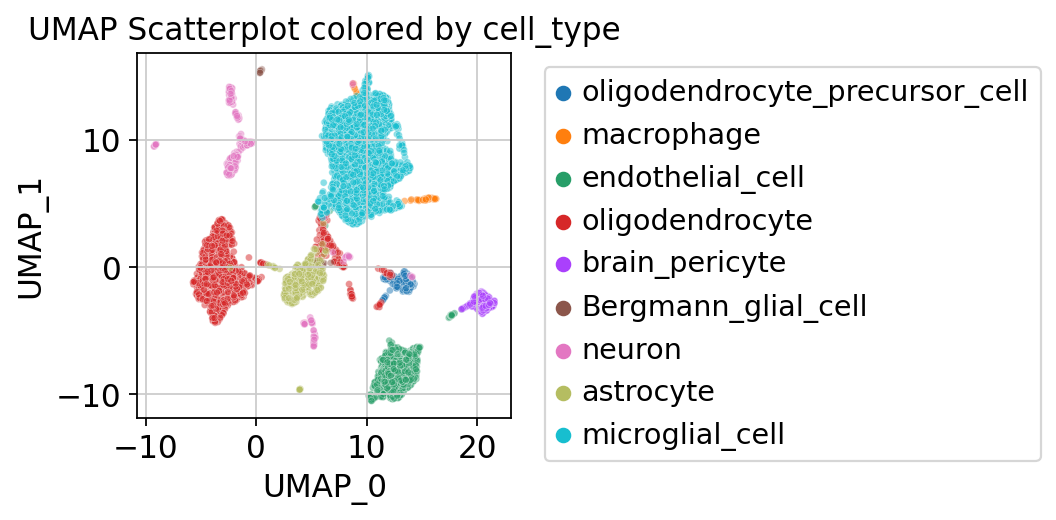

In [13]:
# make scatter plot where x-axis is UMAP_0 and y-axis is UMAP_1
# make colours the cell_type groups in UMAP_rep

# Scatterplot colored by 'cell_type'
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cell_type')
plt.show()


In [14]:
UMAP_rep.cell_type.unique()

array(['oligodendrocyte_precursor_cell', 'macrophage', 'endothelial_cell',
       'oligodendrocyte', 'brain_pericyte', 'Bergmann_glial_cell',
       'neuron', 'astrocyte', 'microglial_cell'], dtype=object)

In [15]:
# figure out which CellState has a value of 1 and assign that cell state number of the cell 
# find columns that have CellState in them?
cellstates = [col for col in UMAP_rep.columns if 'CellState' in col]
UMAP_rep["cellassignment"] = UMAP_rep[cellstates].idxmax(axis=1)

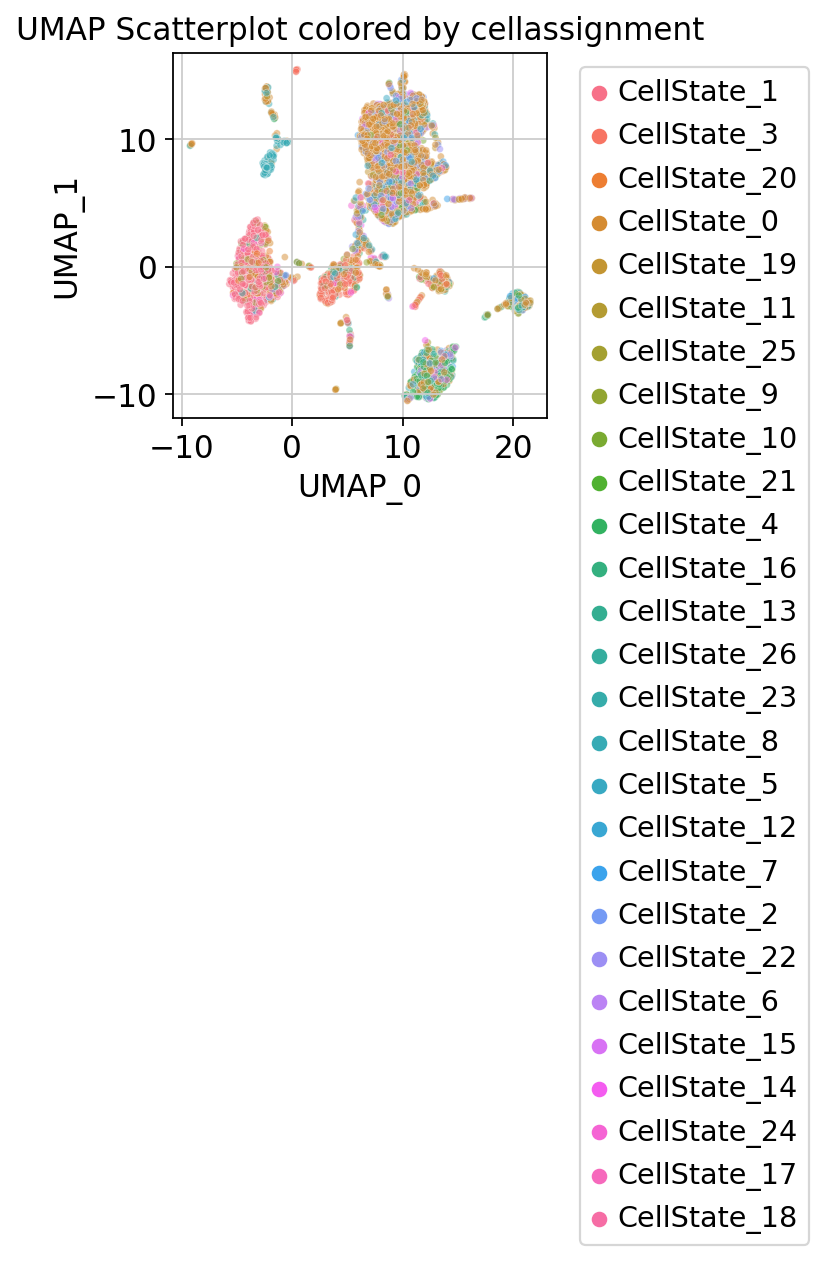

In [16]:
# Scatterplot colored by 'cell_state'
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['cellassignment'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')
plt.show()


Text(0.5, 1.0, 'UMAP Scatterplot colored by cellassignment')

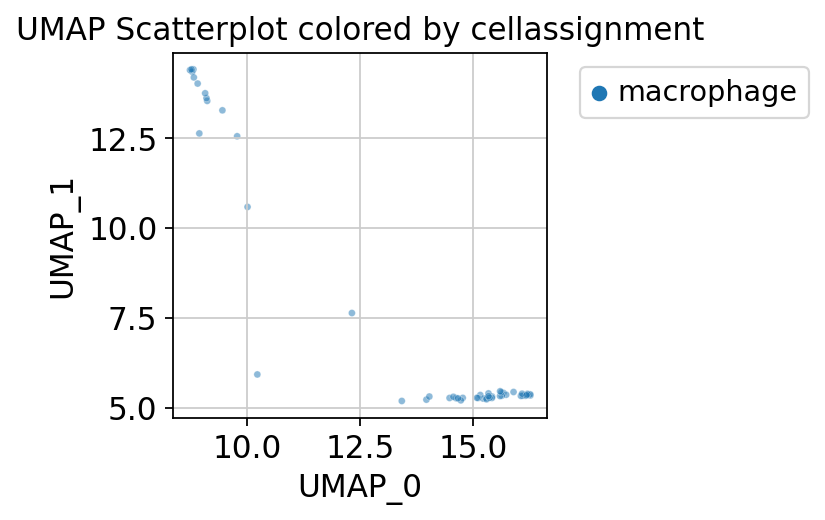

In [17]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(3, 3))
filt_dat=UMAP_rep[(UMAP_rep['cell_type'] == "macrophage")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')

Text(0.5, 1.0, 'UMAP Scatterplot colored by cellassignment')

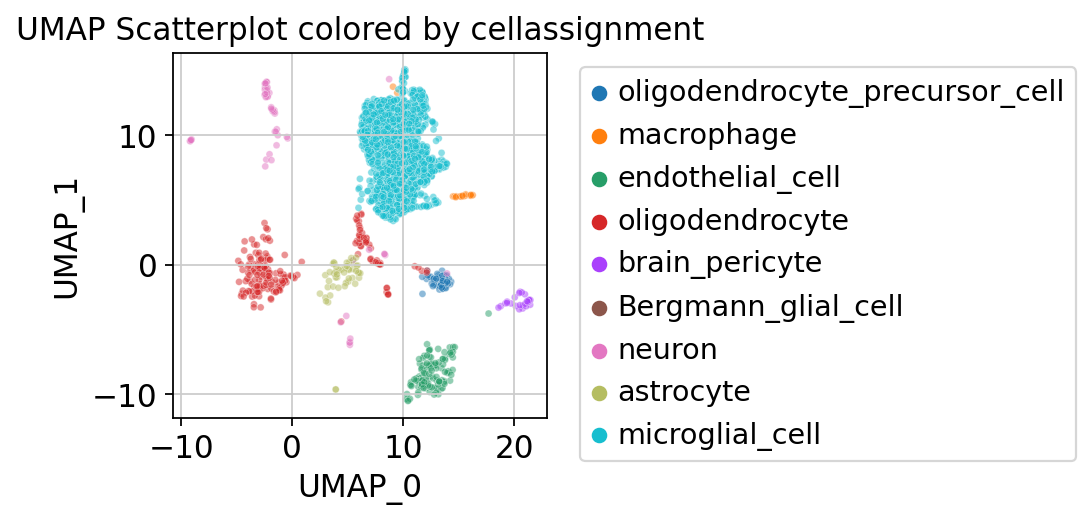

In [18]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(3, 3))
filt_dat=UMAP_rep[(UMAP_rep['cellassignment'] == "CellState_0")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')

Text(0.5, 1.0, 'UMAP Scatterplot colored by cellassignment')

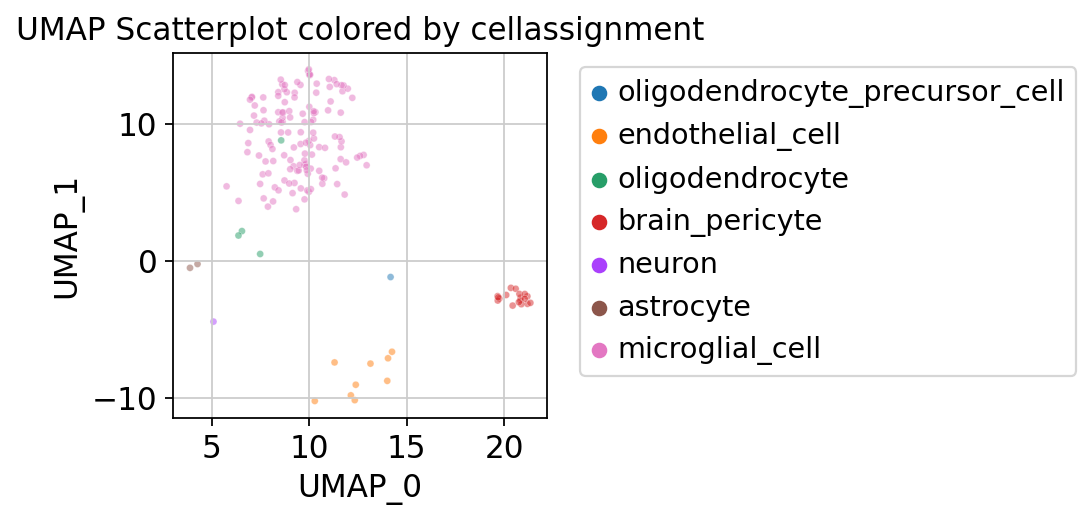

In [19]:
# Scatterplot colored by 'cell_state' but just show cell states 4 and 13 
plt.figure(figsize=(3, 3))
filt_dat=UMAP_rep[(UMAP_rep['cellassignment'] == "CellState_5")]
sns.scatterplot(x=filt_dat["UMAP_0"], y=filt_dat["UMAP_1"], hue=filt_dat['cell_type'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cellassignment')

### basically gene expression can't really seperate macrophages 

In [20]:
UMAP_rep[UMAP_rep["cell_type"] == "macrophage"][("cellassignment")].value_counts()

CellState_0     20
CellState_6      6
CellState_22     3
CellState_2      2
CellState_10     2
CellState_15     2
CellState_7      2
CellState_14     1
CellState_21     1
CellState_19     1
Name: cellassignment, dtype: int64

In [21]:
UMAP_rep[UMAP_rep["cell_type"] == "microglial_cell"][("cellassignment")].value_counts()

CellState_0     1913
CellState_2      227
CellState_5      134
CellState_6      116
CellState_7       99
CellState_17      56
CellState_10      54
CellState_14      53
CellState_12      49
CellState_15      48
CellState_18      47
CellState_13      43
CellState_25      39
CellState_19      33
CellState_22      24
CellState_23      23
CellState_4       16
CellState_21      16
CellState_11      15
CellState_16      13
CellState_26      10
CellState_20       8
CellState_9        5
CellState_24       3
CellState_3        2
CellState_8        2
Name: cellassignment, dtype: int64

In [ ]:
UMAP_rep[UMAP_rep["cell_type"] == "brain_pericyte"][("cellassignment")].value_counts()

In [ ]:
UMAP_rep["cellassignment"].value_counts()

In [ ]:
UMAP_rep.head()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['subtissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cell_type')
plt.show()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['tissue'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cell_type')
plt.show()

In [ ]:
UMAP_rep[["cellassignment", "mouse.id"]][["mouse.id", "cellassignment"]].value_counts()

In [ ]:
plt.figure(figsize=(3, 3))
sns.scatterplot(x=UMAP_rep["UMAP_0"], y=UMAP_rep["UMAP_1"], hue=UMAP_rep['mouse.id'], alpha=0.5, s=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('UMAP Scatterplot colored by cell_type')
plt.show()